# SARIMA Tahmini

## 01 - Arka Plan

Bu zorlukta amacımız, zaman serisi analizinin temel kavramlarını tek boyutlu verilere (tarihe bağlı satışlar) uygulamaktır.

Bu zorlukta aşağıdaki adımları takip edeceğiz:
1. verileri yükle ve görselleştir;
2. modellerimizi eğit ve tahminler yap;
3. seriyi modellemek ve tahmin edebilmek için ekonometrik bir yaklaşım kullan;
4. bu modeli hacklemek için Makine Öğrenmesi kullan.

Veri seti [Machine Learning Mastery](https://github.com/jbrownlee/) tarafından sağlanmıştır. İndirmek için aşağıdaki satırı çalıştırın!

In [23]:
!curl https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly_champagne_sales.csv > data/monthly_champagne_sales.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1596  100  1596    0     0   5451      0 --:--:-- --:--:-- --:--:--  5465


## 02 - Veri Yükleme
Meydan okumanın zaman serisini yükleyerek başlayalım

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/monthly_champagne_sales.csv")
df.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


👉 DataFrame'in "Month" sütununu `Datetime` nesnelerine dönüştürün ve şu şekilde görünmesi için indeks olarak ayarlayın:
<br>

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/monthly_champagne_sales_objective.png" width=180>

In [25]:
# First, convert the column to Datetime
df["Month"] = pd.to_datetime(df["Month"], infer_datetime_format=True)

# Next, we reset the index and set it to the Month column
df = df.set_index(df["Month"])

# Now we no longer need the original column, so we drop it
df = df.drop("Month", axis=1)

df.head()

/var/folders/f5/03l_rw613wq46r0kz1rz5f380000gn/T/ipykernel_87680/3846107846.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["Month"] = pd.to_datetime(df["Month"], infer_datetime_format=True)


,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


### Alternatif - Pandas'ın İşi Yapmasına İzin Ver

In [26]:
# We can also use pandas magic to handle the conversions from the start
df = pd.read_csv("data/monthly_champagne_sales.csv", parse_dates=['Month'], index_col='Month')
df.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


## 04 - Veriyi Görselleştir ve Yorumla

Aferin, bu yeniden indeksleme sayesinde artık "Sales" (y-ekseni) değerlerini zamanın (x-ekseni) bir fonksiyonu olarak kolayca çizebilmelisiniz

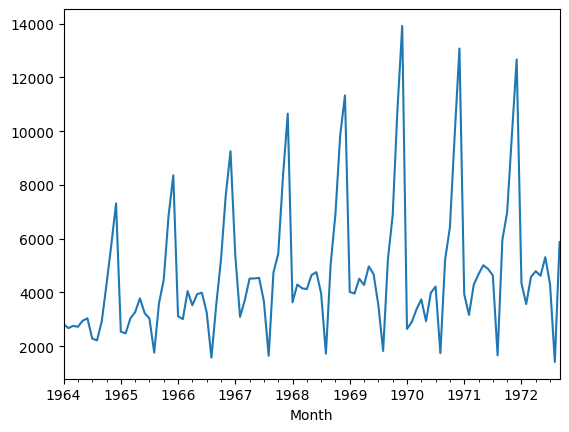

In [27]:
df["Sales"].plot();

Kodunuz doğruysa, bu zaman serisinin (TS) şu özelliklere sahip olduğunu görebilmelisiniz:
- Durağan değil (ortalama ve varyans sabit değil).
- Güçlü mevsimsellik sergiliyor.
- Bir trend var gibi görünüyor.

Verilerin **trend**, **mevsimsellik** ve **gürültü** arasındaki ayrışımını görelim. Bunun için statsmodels'ın [`seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) fonksiyonunu kullanmalısınız. Dokümanları okuyun ve bu fonksiyonun ne yaptığını ve nasıl kullanıldığını anladığınızdan emin olun, ardından:
1. "Sales"i "additive" model ile çizin
2. "Sales"i "multiplicative" model ile çizin

Profesyonel ipuçları: çift çizim sorunlarını önlemek için statsmodels plot metot çağrılarınızı noktalı virgülle (`;`) bitirin!

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_add = seasonal_decompose(df["Sales"], model="additive")
decomp_mult = seasonal_decompose(df["Sales"], model="multiplicative")

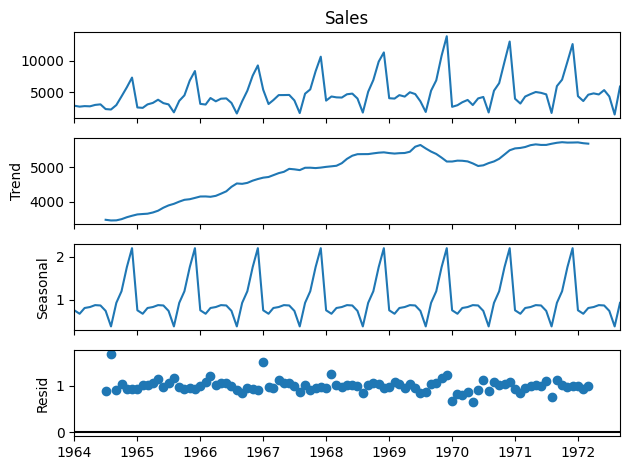

In [29]:
decomp_mult.plot();

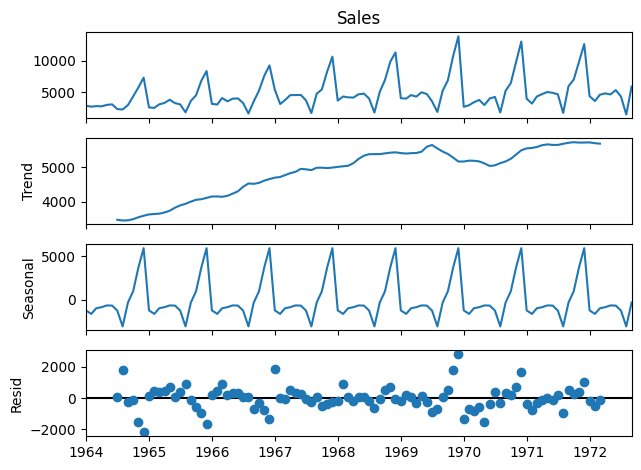

In [30]:
decomp_add.plot();

👉 Seçtiğiniz ayrışımı kullanarak bu zaman serisini mevsimsellikten arındırın

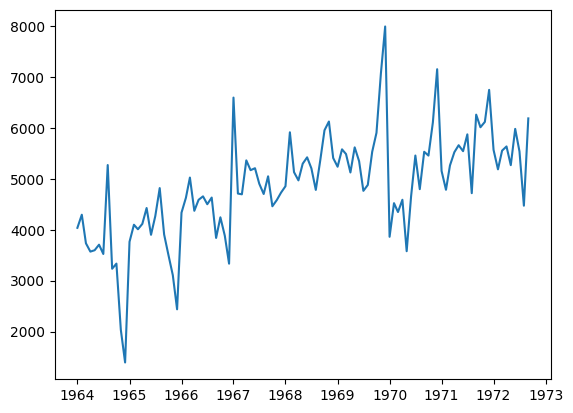

In [31]:
plt.plot(df.Sales - decomp_add.seasonal);

☝️ Bu zaman serisinin "mevsimsellikten arındırılmış" versiyonuna bir ARIMA modeli uydurabilir ve tahminimizden sonra tekrar birleştirebiliriz. Ancak bu meydan okumada, orijinal zaman serisine _doğrudan_ uydurmak için SARIMA modellerini kullanacağız!

## 05 - Veriyi Böl (eğitim/test)


Zaman serileri için test setinde bulunacak noktaları rastgele örnekleyemeyiz. Test setinin "zaman-dışı" olması gerekir, yani test setinin kesinlikle geleceğinde olmalıdır. Bu egzersiz için eğitim için 1970'e kadar olan verileri kullanacağız ve bundan sonraki her şey test için kullanılacak.

👉 `df_train` ve `df_test` oluşturun, DataFrame'i eğitim için 1970 öncesinde ve test için sonrasında (veya eşit) bölerek

In [32]:
df_train = df[:'1969']
df_test = df['1970':]
print(df_train.shape)
print(df_test.shape)

(72, 1)
(33, 1)


In [33]:
print("train shape: {}, test shape: {}".format(df_train.shape,df_test.shape))

train shape: (72, 1), test shape: (33, 1)


## 06 - SARIMA
Veriyi SARIMA modeli (Seasonal Auto-Regressive Integrated Moving Average - Mevsimsel Oto-Regresif Entegre Hareketli Ortalama) kullanarak analiz edeceğiz.


Yapmamız gerekenler:
- zaman serisini nasıl durağanlaştıracağımızı bul (SARIMA'daki I)
- oto-regresif (AR) kısmını bul
- hareketli ortalama (MA) kısmını bul
- mevsimselliği (S) bul

### Adım 1: Durağanlığı Kontrol Et

Bir zaman serisinin trend veya mevsimsellik bileşeni varsa, tahmin için ARIMA kullanabilmek için önce durağan hale getirilmelidir.

Yukarıdaki grafiğe bir bakış, zaman serisinin durağan olmadığına sizi ikna etmeye yeterli olmalıdır.

[`Augmented Dick Fuller testi`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) ve özellikle p-değerini kullanarak `df["Sales"]`ın durağanlığını tekrar kontrol edin

In [34]:
from statsmodels.tsa.stattools import adfuller

print('p-value: ', adfuller(df_train["Sales"])[1])

p-value:  0.7753855460224333


Durağanlıkta %95 güvene sahip olmak için p-değeri 0.05'ten küçük olmalıdır.

Eğer p-değeri 0.05'ten büyükse, null hipotezi reddedemeyiz (null hipotez = "süreç durağan değildir").

İdeal olarak, p 0.05'ten *çok* küçük olmalıdır.

Durağanlığı aramanın başka bir yolu otokorelasyon fonksiyonuna (ACF) bakmaktır.

Zaman serisinin ACF'sini çizin. Lag 12'de büyük bir pik görmelisiniz, bu güçlü yıllık mevsimselliği gösterir.

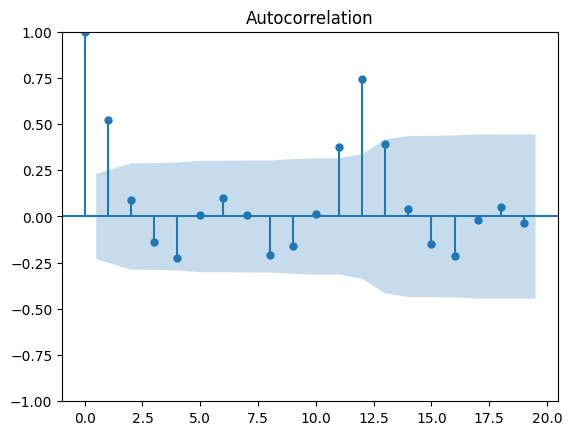

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = df_train.Sales
plot_acf(y);

### Adım 2 - Mevsimsel Farklaştırma (D)

12 aylık periyodla güçlü bir mevsimselliğimiz var.

Zaman serisi üzerinde **lag 12'nin mevsimsel farklaştırmasını** yapın, farklaştırılmış veriyi çizin ve ACF grafiğini (+ADF testi) tekrar kontrol edin.

NaN'ları düşürmeyi unutmayın.

p-value:  2.6473506362550414e-09


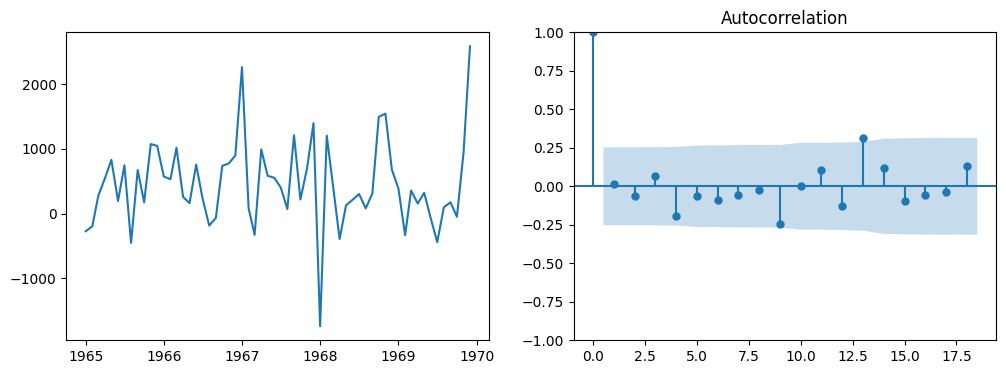

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

y_diff_12 = df_train.Sales.diff(12).dropna()

axes[0].plot(y_diff_12)
plot_acf(y_diff_12, ax=axes[1])

print('p-value: ', adfuller(y_diff_12)[1])

☝️ TS'yi durağanlaştırmak için tek bir mevsimsel farklaştırma yeterli görünüyor.
SARIMA(p,d,q, P,D,Q,m) için D=1 (1 mevsimsel fark) ve m=12 (mevsimsellik = 12)

### Adım 3 - Farklaştırma (d)

Zaman serisi hala durağan değilse, *farklaştırma* yoluyla durağanlaştırılması gerekir. Bu, her değer ile bir önceki arasındaki farkı almak (*birinci fark*) anlamına gelir.

Mevsimselliği çıkardıktan sonra daha fazla farklaştırmaya ihtiyacımız var mı?

diff(12) seriniz üzerinde ek bir birinci derece diff(1) çalıştırdıktan sonra ACF ve ADF'yi kontrol edin.

p-value:  0.0005183923752540721


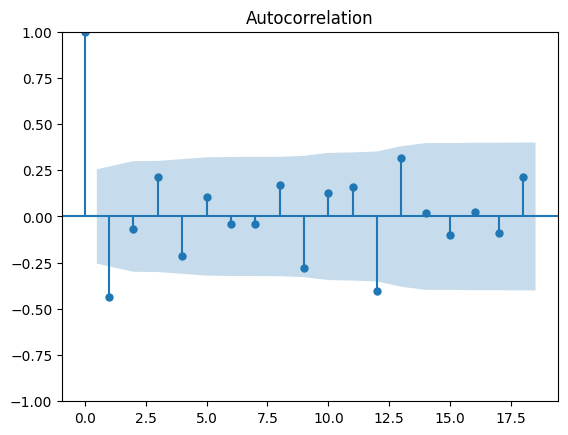

In [37]:
plot_acf(y_diff_12.diff(1).dropna());
print('p-value: ', adfuller(y_diff_12.diff(1).dropna())[1])

👉 Ek farklaştırma hem p-değerini hem de ACF'yi daha kötü hale getirdi!
(d=0) ve (D=1) seçebiliriz

### Adım 4 - AR(p, P) ve MA(q, Q) Terimlerini Seç

Şimdi bir AR terimi, MA terimi veya her ikisini de dahil edip etmeyeceğinize karar vermek için ACF ve PACF grafiklerini kullanacaksınız.

- **Tamamen farklaştırılmış** serinize uygulanan otokorelasyon grafiği ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) bir MA sayısı (`q`) seçmenize olanak tanır
- MA($\color{blue}{q}$) = $Y^{\color{green}{(d+D)}}$'nin $\color{blue}{ACF}$'sinin kestiği lag sayısı


- **Tamamen farklaştırılmış** serinize uygulanan kısmi otokorelasyon grafiği [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) AR (`p`) seçmenize olanak tanır
- AR($\color{red}{p}$) = $Y^{\color{green}{(d+D)}}$'nin $\color{red}{PACF}$'sinin kestiği lag sayısı

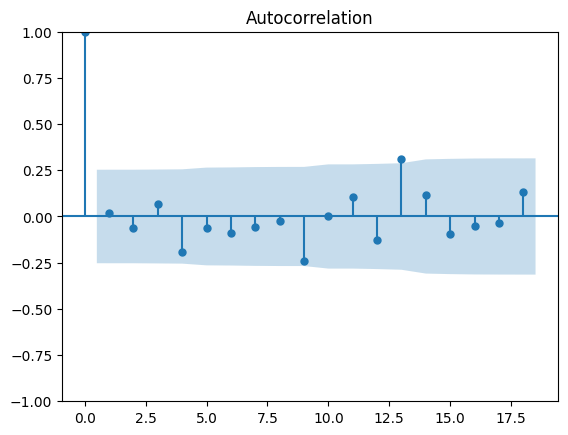

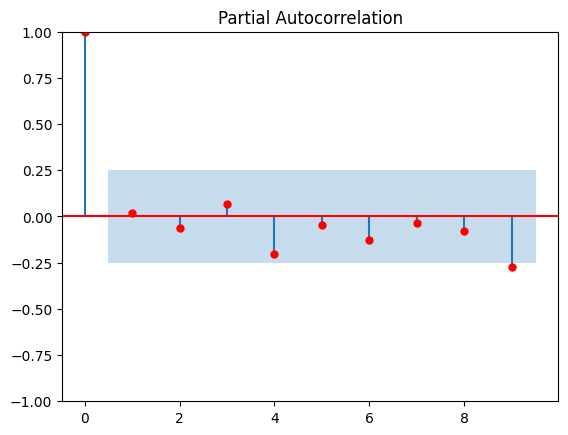

In [38]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(y_diff_12);
plot_pacf(y_diff_12, lags=np.arange(10), method='ywm',c='red');

☝️ ACF veya PACF'de anlamlı pik yok gibi görünüyor, bu yüzden büyük olasılıkla p=q=0.
SARIMA için ilk tahminimiz bu nedenle d=0, p=q=0, D=1 ve m=12.

P ve Q değerlerini nasıl bulacağız? Burada, `pdarima`'nın bizim için grid_search ile P ve Q için 1 ve 0 değerlerini denemesine izin vereceğiz.
Bu katsayıları kendiniz bulmak istiyorsanız, bazı pratik kurallar için [bunu okuyun](https://analyticsindiamag.com/quick-way-to-find-p-d-and-q-values-for-arima/)

👉 Eğitim seti için [auto_arima](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) çalıştırın. seasonal=True, m=12 ve D=1 ayarlayın. p ve q, P ve Q'yu 0'dan 2'ye kadar arayın. Ardından model.summary() ile modelin özetini yazdırın.
`njobs=-1, trace=True, error_action='ignore', suppress_warnings=True` kullanın

In [39]:
import pmdarima as pm

In [40]:
model = pm.auto_arima(
    df_train['Sales'],
    m=12, # frequency of series. Important to choose manually
    seasonal=True,
    stepwise=True,  # only check the most interesting combination. False will take way longer.
    start_p=0, max_p=2,
    start_d=0, max_d=1,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_D=0, max_D=2,
    start_Q=0, max_Q=2,
    njobs=-1, trace=True, error_action='ignore',  suppress_warnings=True
)

print(model.summary())

/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=954.252, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=957.794, Time=0.66 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=957.973, Time=0.08 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=974.624, Time=0.02 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=956.000, Time=0.04 sec


/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=955.904, Time=0.12 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=957.929, Time=0.06 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=956.182, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=956.250, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=958.187, Time=0.05 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 1.109 seconds
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Observations:                   72
Model:             SARIMAX(0, 1, 0, 12)   Log Likelihood                -475.126
Date:                  Thu, 12 Mar 2026   AIC                            954.252
Time:                          11:40:44   BIC                            958.441
Sample:                      01-01-1964   HQIC                           955.891
                           - 12-01-1969                                         
Covariance Type:         

/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Bulunan en iyi model `ARIMA(0,0,0)(0,1,0)[12]`!
Bu, düşünülen zaman serisinin basit "mevsimsel farklaştırma"nın ötesinde herhangi bir "oto-regresif" veya "hareketli ortalama" modelleme eklemeyi haklı çıkarmadığı anlamına gelir.

Böyle "zayıf" bir model muhtemelen sadece tespit edilen son mevsimsel desenin tekrarını ve ortalama artan trendin uzatılmasını tahmin edecektir. Kontrol edelim

👉 Aşağıdaki üç tahmini kaydetmek için `n_periods` = test setinin uzunluğu ile `model.predict` kullanın
- `central`
- `upper`
- `lower`

Bunları Pandas Series olarak kaydedin ve `y_test`inizle aynı indeks ile indeksleyin

In [41]:
# Forecast
n_periods = len(df_test)
central, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
index_y_test = df_test.index #pd.date_range(df_test.index[-1], periods = n_periods, freq='MS')

# Make series for plotting purpose
central = pd.Series(central, index=index_y_test)
lower = pd.Series(conf_int[:, 0], index=index_y_test)
upper = pd.Series(conf_int[:, 1], index=index_y_test)

/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


👇 Tahminlerinizi gerçeklikle karşılaştırmak için aşağıdaki hücreyi çalıştırın

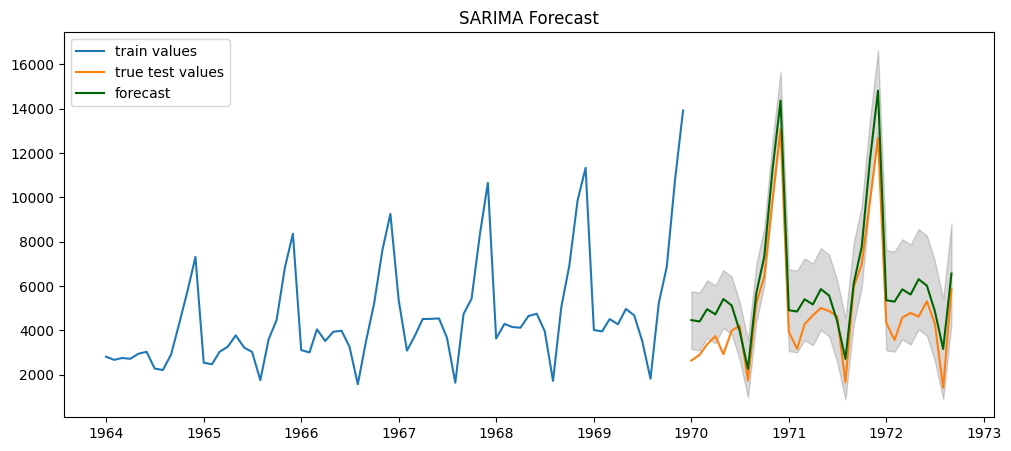

In [42]:
# Plot
plt.figure(figsize=(12, 5), dpi=100)

plt.plot(df_train, label = "train values")
plt.plot(df_test, label = "true test values")
plt.plot(central, color='darkgreen',label = "forecast")

plt.fill_between(
    lower.index,
    lower,
    upper,
    color='k', alpha=.15
)

plt.title("SARIMA Forecast")
plt.legend()
plt.show()

👉 SARIMA'nızda `p`, `d`, `P`, `D`'ye null olmayan değerler atamayı deneyin ve etkileri karşılaştırmak için bu grafiği yeniden çizin!

# İSTEĞE BAĞLI - Makine Öğrenmesi Yaklaşımı

### Sadece 1 aylık tahmin ufku olan model

Şimdi Random Forest gibi doğrusal olmayan bir model uyduruyoruz. Fikir, son değerlerden bir değer tahmin etmektir.

👉 `df`'de `df['Sales']`'ın kaydırılmış versiyonu olan yeni sütunlar oluşturun. Bunu 1'den 12'ye kadar kaydırma ile yapın.

In [43]:
# Add lagged values
df2 = df.copy()
for i in range(1, 13):
    df2[f'x_{i}'] = df["Sales"].shift(i)

# Drop nan
df2 = df2.dropna()

# create df_train and df_test
df2_train = df2[:'1969']
df2_test = df2['1970':]

In [44]:
# Keep track of test_indexes
test_indexes = np.arange(len(df2_train), len(df2_train)+len(df2_test))
test_indexes

array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76,
       77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92])

In [45]:
# Create X, y
y = df2['Sales']
X = df2.drop(columns=['Sales'])

👉 Kaydırılmış özelliklerinize dayalı olarak Satışları tahmin etmek için bir `random forest` algoritması oluşturun (eğitmeyin)

In [49]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(n_estimators=20, random_state=0)

👉 Test etmek için aşağıdaki fonksiyonu kullanabilirsiniz. Gerçek y değerlerini (`data` NumPy array olmalı), test örneklerinin indekslerini (`test_indexes`), tahmin ediciyi (`predictor`: random forest algoritmanız) ve kaydırılmış sütunları (`full_X` NumPy array olmalı) alır.

In [46]:
# For each predictor, design a method to evaluate its performance on the test set:
from sklearn.metrics import r2_score

def evaluate_performance_month_prediction(y_true, test_indexes, predictor, full_X):
    predictions = []
    ground_truth = []
    i = 0

    for _index in test_indexes:
        train_data = y_true[:_index]
        current_ground_truth = y_true[_index]
        current_ground_truth_features = full_X[_index,:]
        train_features = full_X[:_index]

        # train the model on all data points until (t-1) to predict (t)
        predictor.fit(train_features, train_data)
        prediction = predictor.predict(current_ground_truth_features.reshape(1,-1))[0]
        predictions.append(prediction)
        ground_truth.append(current_ground_truth)

        i += 1

    mape = np.mean(np.abs(np.array(predictions) - np.array(ground_truth))/np.abs(np.array(ground_truth)))

    return ground_truth, predictions, mape

In [50]:
results = evaluate_performance_month_prediction(
    y.values,
    test_indexes=test_indexes,
    predictor=random_forest,
    full_X = X.values
)

In [51]:
print('Mean Absolute Prediction Error MAPE')
results[2]

Mean Absolute Prediction Error MAPE


0.16347530372802851

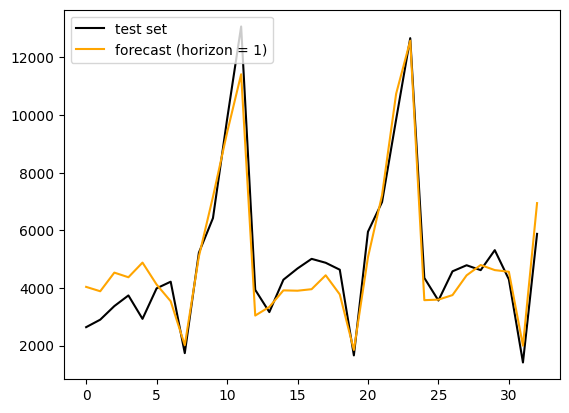

In [52]:
plt.plot(results[0], c='black', label='test set')
plt.plot(results[1], c='orange', label='forecast (horizon = 1)')
plt.legend()

Modelimizi iyileştirmek için özellik mühendisliği yapabiliriz. Random forest'ı eğitmek için kullanılan verilere hareketli ortalamalar ekleyeceksiniz.

`df`'de 3 yeni sütun oluşturmayı deneyin: biri 12 pencereli `df[Sales]`'ın hareketli ortalaması, biri 3 pencereli ve biri 2 pencereli. Bu, trendi izole etme ve algoritmanın öğrenmesine izin verme etkisine sahip olacaktır. Bu verileri çizin.


In [53]:
# Extract the trend using a well-chosen moving average
df2['ma_12'] = df2['Sales'].rolling(window=12).mean()
df2['ma_3'] = df2['Sales'].rolling(window=3).mean()
df2['ma_2'] = df2['Sales'].rolling(window=2).mean()

<Axes: xlabel='Month'>

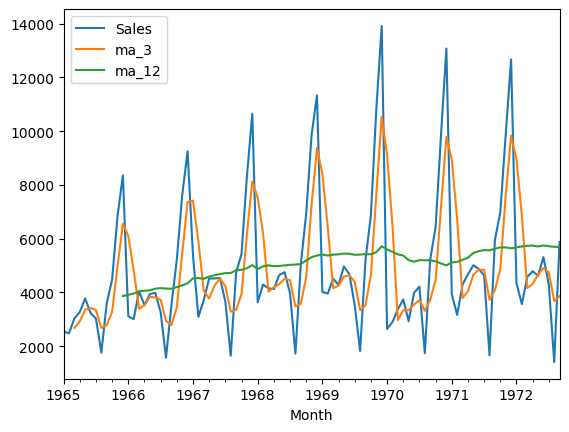

In [54]:
df2[["Sales","ma_3", "ma_12"]].plot()

İstatistiksel olarak bir AR sürecini optimize eden üstel hareketli ortalama kullanarak daha güçlü bir yumuşatma tahmincisi de ekleyebilirsiniz (ipucu: 2, 3 ve 12 `halflife` ile `.ewm` metodu). Bu verileri çizin.

In [55]:
df2["ewma_2"] = df2["Sales"].ewm(halflife=2).mean()
df2["ewma_3"] = df2["Sales"].ewm(halflife=3).mean()
df2["ewma_12"] = df2["Sales"].ewm(halflife=12).mean()

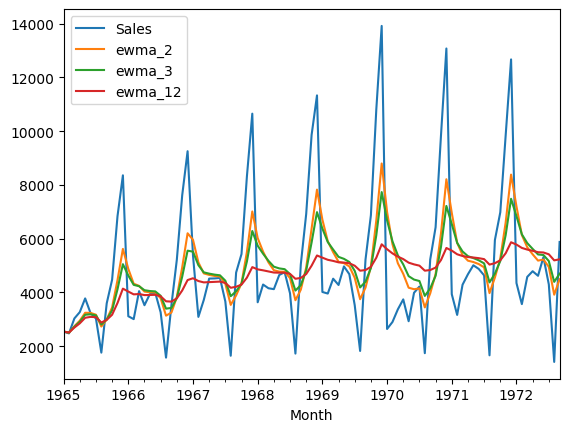

In [57]:
df2[["Sales", "ewma_2", "ewma_3", "ewma_12"]].plot();

In [58]:
random_forest = RandomForestRegressor(n_estimators=20, random_state=12)

features = [
    "ewma_2", "ewma_3", "ewma_12", "ma_2", "ma_3", "ma_12", "x_1",
    "x_2", "x_3", "x_4", "x_5", "x_6", "x_7", "x_8", "x_9", "x_10", "x_11", "x_12"
]

new_features = df2[features].fillna(0).values

results = evaluate_performance_month_prediction(
    df2["Sales"].values,
    test_indexes=test_indexes,
    predictor=random_forest,
    full_X = new_features
)


In [59]:
results[2]

0.147890158319115

Daha iyi bir MAPE görmelisiniz!

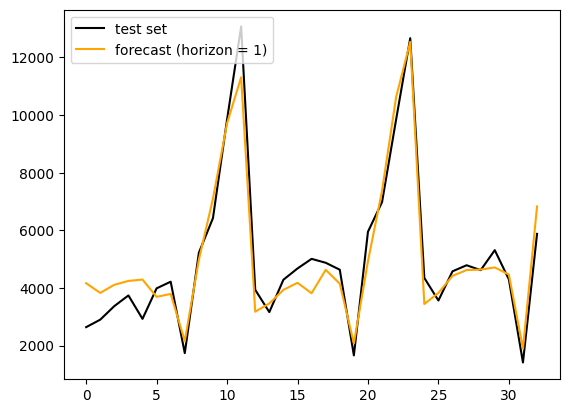

In [61]:
plt.plot(results[0], c='black', label='test set')
plt.plot(results[1], c='orange', label='forecast (horizon = 1)')
plt.legend();

Her özelliğin önemine bakmayı deneyin. Ne buluyorsunuz?


In [60]:
importances = random_forest.feature_importances_
pd.DataFrame(zip(importances, features)).sort_values(by=0, ascending=False)

,0,1
17,0.821873,x_12
3,0.062603,ma_2
7,0.020262,x_2
16,0.017454,x_11
1,0.014037,ewma_3
4,0.010594,ma_3
8,0.008481,x_3
15,0.007970,x_10
2,0.006503,ewma_12
11,0.005091,x_6


### Örneklem-Dışı Tahmin Modelleri

Şimdi "örneklem-dışı" tahminde SARIMA'yı geçmeyi deneyelim.

👉 _Her tahmin ufku için bir model eğitin_ (`1`-aylık ufuktan `len(y_test)` aya kadar)
👉 MAPE'yi değerlendirin ve SARIMA ile karşılaştırın

/Users/berkayturhan/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/f5/03l_rw613wq46r0kz1rz5f380000gn/T/ipykernel_87680/3092918725.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "true_values": df2.Sales[test_indexes],


<Axes: >

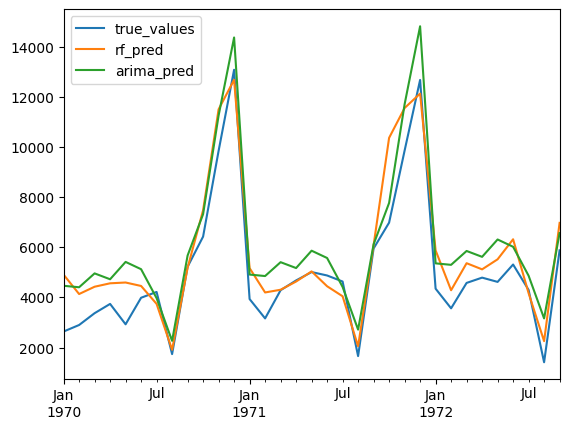

In [62]:
# Initialize the random forest for predicting at each time step
random_forest_dict = {  # prediction horizon: model (1 is predicting at t+1, 2 at t+2...)
    i: RandomForestRegressor(n_estimators=20, random_state=0) for i in range(1, len(df_test) + 1)
}
# Do we have as much forests as there are test periods?
assert len(random_forest_dict) == df2_test.shape[0]
# Prepare data
X_train = new_features[:df2_train.shape[0], :]
y_train = df2.Sales[:df2_train.shape[0]]
X_test = new_features[df2_train.shape[0]:, :]
# Train models
for h in range(1, len(df_test) + 1):  # Setting the prediction horizon
    if h == 1:  # Dealing with exceptional behaviour when slicing [:-0,:]
        X_train_horizon = X_train
    else:
        X_train_horizon = X_train[:-(h - 1), :]
    y_train_horizon = y_train[(h - 1):]
    random_forest = random_forest_dict[h]
    random_forest.fit(X=X_train_horizon, y=y_train_horizon)
# Predicting test values with RF
x = X_test[0, :].reshape([1, X_train.shape[1]])
y_test_pred_rf = np.array([random_forest_dict[h].predict(X=x) for h in range(1, len(df_test) + 1)])[:, 0]
# Predicting test values with SARIMA
y_test_pred_arima = model.predict(n_periods=len(df_test), return_conf_int=False)
# Plot
pred_df = pd.DataFrame(
    {
        "true_values": df2.Sales[test_indexes],
        "rf_pred": y_test_pred_rf,
        "arima_pred": y_test_pred_arima,
    })
pred_df.plot()
